In [1]:
import cv2
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:

# Function to draw a smaller, centered 3x3 grid on an image
def draw_centered_grid(image, grid_size=200):
    h, w, _ = image.shape
    center_x, center_y = w // 2, h // 2

    # Calculate the grid boundaries
    half_size = grid_size // 2
    top_left_x, top_left_y = center_x - half_size, center_y - half_size
    bottom_right_x, bottom_right_y = center_x + half_size, center_y + half_size

    # Draw the grid
    cell_size = grid_size // 3
    for i in range(4):
        y = top_left_y + i * cell_size
        x = top_left_x + i * cell_size
        cv2.line(image, (top_left_x, y), (bottom_right_x, y), (255, 255, 255), 2)
        cv2.line(image, (x, top_left_y), (x, bottom_right_y), (255, 255, 255), 2)

    return image, (top_left_x, top_left_y, cell_size)


# Function to detect the dominant color in a square
def detect_dominant_color(square, neighborhood_fraction=0.5, blur_ksize=5):
    h, w, _ = square.shape
    center_x, center_y = w // 2, h // 2

    # Define the neighborhood size
    offset_x = int(w * neighborhood_fraction // 2)
    offset_y = int(h * neighborhood_fraction // 2)

    # Extract the neighborhood region
    neighborhood = square[center_y - offset_x:center_y + offset_x, center_x - offset_y:center_x + offset_y]

    # Apply Gaussian blur to the neighborhood
    blurred = cv2.GaussianBlur(neighborhood, (blur_ksize, blur_ksize), 0)

    # Calculate the average color in the blurred neighborhood
    avg_color = blurred.mean(axis=0).mean(axis=0)
    return tuple(map(int, avg_color))  # Convert to (B, G, R)


# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

captured_faces = []  # List to store captured face images
color_data = []  # List to store color data for each face
capture_limit = 6  # Number of faces to capture

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Draw the smaller, centered 3x3 grid on the frame
    grid_frame, grid_info = draw_centered_grid(frame.copy(), grid_size=200)

    # Display the live webcam feed with the smaller grid overlay
    cv2.imshow('Align Your Cube and Press Space', grid_frame)

    key = cv2.waitKey(1)

    if key == ord('q') or key == 27:  # Quit on 'q' or 'Esc'
        break
    elif key == ord(' '):  # Capture on spacebar
        if len(captured_faces) < capture_limit:
            captured_faces.append(frame.copy())
            print(f"Captured face {len(captured_faces)}")

            # Analyze grid colors
            top_left_x, top_left_y, cell_size = grid_info
            colors = []
            for i in range(3):
                for j in range(3):
                    x1 = top_left_x + j * cell_size
                    y1 = top_left_y + i * cell_size
                    x2 = x1 + cell_size
                    y2 = y1 + cell_size
                    square = frame[y1:y2, x1:x2]
                    dominant_color = detect_dominant_color(square)
                    colors.append(dominant_color)
            color_data.append(colors)
        else:
            print("All 6 faces have already been captured!")

    # Check if all faces are captured
    if len(captured_faces) == capture_limit:
        break

cap.release()
cv2.destroyAllWindows()

print(color_data)
# Display the final color palette
if len(color_data) == capture_limit:
    # Create a blank canvas for the color palette
    palette_height = 300
    palette_width = 600
    palette = np.zeros((palette_height, palette_width, 3), dtype=np.uint8)

    face_width = palette_width // 6  # Width of each face in the palette
    cell_size = face_width // 3     # Size of each cell within a face

    for face_idx, face_colors in enumerate(color_data):
        for i in range(3):
            for j in range(3):
                color = face_colors[i * 3 + j]
                top_left_x = face_idx * face_width + j * cell_size
                top_left_y = i * cell_size
                bottom_right_x = top_left_x + cell_size
                bottom_right_y = top_left_y + cell_size
                cv2.rectangle(
                    palette,
                    (top_left_x, top_left_y),
                    (bottom_right_x, bottom_right_y),
                    color,  # Convert BGR to RGB for OpenCV
                    -1  # Filled rectangle
                )

    # Show the color palette
    cv2.imshow('Cube Color Palette', palette)

    # Wait for user input to close the window
    print("Press any key in the 'Cube Color Palette' window to close.")
    while True:
        if cv2.waitKey(1) & 0xFF in {ord('q'), 27}:  # Quit on 'q' or 'Esc'
            break

    # Destroy the palette window
    cv2.destroyAllWindows()

Captured face 1
Captured face 2
Captured face 3
Captured face 4
Captured face 5
Captured face 6
[[(1, 91, 77), (3, 68, 0), (55, 25, 9), (11, 30, 149), (80, 75, 78), (0, 72, 0), (86, 81, 83), (85, 82, 82), (87, 82, 83)], [(74, 68, 68), (72, 66, 68), (2, 64, 0), (15, 1, 133), (10, 25, 131), (57, 23, 7), (11, 31, 154), (71, 68, 69), (0, 99, 84)], [(18, 3, 133), (0, 92, 78), (1, 67, 0), (83, 77, 77), (0, 75, 0), (0, 73, 0), (70, 30, 10), (0, 109, 92), (71, 29, 9)], [(20, 4, 129), (55, 26, 12), (70, 64, 65), (0, 97, 82), (13, 0, 133), (10, 24, 126), (2, 73, 0), (53, 24, 13), (11, 26, 121)], [(20, 34, 126), (0, 92, 77), (0, 90, 75), (14, 32, 147), (64, 26, 9), (13, 0, 139), (15, 0, 155), (10, 32, 157), (12, 0, 152)], [(18, 30, 132), (54, 26, 11), (51, 23, 8), (15, 0, 137), (0, 97, 82), (12, 1, 129), (0, 100, 86), (0, 75, 0), (1, 72, 0)]]
Press any key in the 'Cube Color Palette' window to close.


In [3]:
import numpy as np

# Assuming lab_data_flat is defined elsewhere in your code
data = np.array(color_data, dtype=np.uint8).reshape(-1, 3)
# Initialize adjacency matrix
adjacency_matrix = np.zeros((54, 54), dtype=float)

# Calculate distances and fill the adjacency matrix
for x in range(54):
    for y in range(x, 54):  # Only need to calculate for y >= x (since adjacency is symmetric)
        a = data[x]
        b = data[y]
        distance = np.linalg.norm(b.astype(np.int16) - a.astype(np.int16))  # Correct overflow
        adjacency_matrix[x, y] = distance
        adjacency_matrix[y, x] = distance

# Find groups of 9 nearest neighbors without repeating
clusters = []
used = []
for c in range(6):
    lowest_weight = (0, np.inf)
    for i in range(54):
        if i in used:
            continue  # Skip indices that are already used
        row = np.copy(adjacency_matrix[i])
        row_zipped = sorted(
            [(idx, val) for idx, val in enumerate(row) if idx not in used], 
            key=lambda x: x[1]
        )[:9]  # Get 9 nearest unused neighbors
        total_weight = sum(val for _, val in row_zipped)
        if total_weight < lowest_weight[1]:
            lowest_weight = (i, total_weight)

    # Add the selected index and its neighbors to 'used' one by one
    selected_index = lowest_weight[0]
    row = np.copy(adjacency_matrix[selected_index])
    row_zipped = sorted(
        [(idx, val) for idx, val in enumerate(row) if idx not in used], 
        key=lambda x: x[1]
    )[:9]
    neighbors = [idx for idx, _ in row_zipped]
    
    # Append selected index and neighbors to 'used'
    used.append(selected_index)
    for neighbor in neighbors:
        used.append(neighbor)

    # Print the neighbors without duplicating the first index
    clusters.append(sorted(neighbors))

for i, cluster, in enumerate(clusters):
    print(f'Cluster {i+1}: {cluster}')


Cluster 1: [1, 5, 11, 20, 22, 23, 33, 52, 53]
Cluster 2: [0, 17, 19, 25, 30, 37, 38, 49, 51]
Cluster 3: [2, 14, 24, 26, 28, 34, 40, 46, 47]
Cluster 4: [12, 18, 27, 31, 41, 42, 44, 48, 50]
Cluster 5: [4, 6, 7, 8, 9, 10, 16, 21, 29]
Cluster 6: [3, 13, 15, 32, 35, 36, 39, 43, 45]


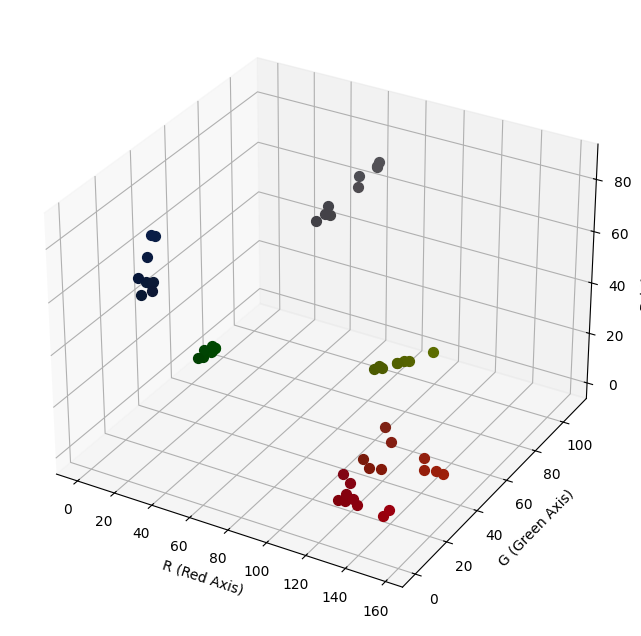

In [4]:

import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming lab_data_bgr is in BGR format (values in range [0, 255])
# Convert BGR to LAB using OpenCV
data_reshaped = data[np.newaxis, :, :]  # Shape becomes (1, N, 3)
rgb_array = cv2.cvtColor(data_reshaped, cv2.COLOR_BGR2RGB)[0]
rgb_colors = rgb_array / 255.0  # Normalize to [0, 1] for plotting

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of all points in LAB space with original colors
for i in range(54):
    ax.scatter(data[i][2], data[i][1], data[i][0], color=rgb_colors[i], s=50)

# Highlight specific points
highlights = []  # Specify indices of points to highlight
for h in highlights:
    ax.scatter(
        data[h][2], data[h][1], data[h][0], color='red', s=100, edgecolors='black', label="Highlighted Point"
    )

# Add labels and title
ax.set_xlabel('R (Red Axis)')
ax.set_ylabel('G (Green Axis)')
ax.set_zlabel('B (Blue Axis)')
# Show the plot
plt.show()

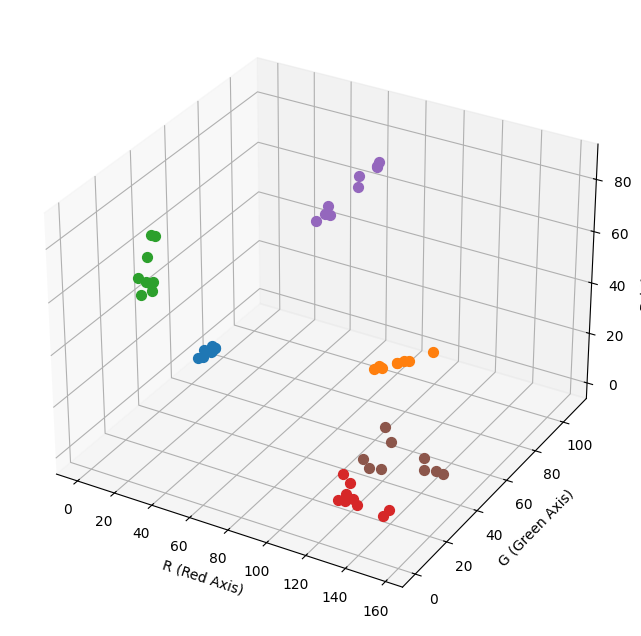

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming lab_data_bgr is in BGR format (values in range [0, 255])
# Convert BGR to LAB using OpenCV
data_reshaped = data[np.newaxis, :, :]  # Shape becomes (1, N, 3)
rgb_array = cv2.cvtColor(data_reshaped, cv2.COLOR_BGR2RGB)[0]
rgb_colors = rgb_array / 255.0  # Normalize to [0, 1] for plotting

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for i,cluster in enumerate(clusters):
    colour = colours[i]
    for point in cluster:
        ax.scatter(data[point][2], data[point][1], data[point][0], color=colour, s=50)

ax.set_xlabel('R (Red Axis)')
ax.set_ylabel('G (Green Axis)')
ax.set_zlabel('B (Blue Axis)')
# Show the plot
plt.show()

In [6]:
# Define cluster-to-color mapping
centre_indices = [4, 22, 13, 31, 40, 49]
picture_order = [0, 1, 2, 3, 4, 5]
color_order = ['W', 'G', 'O', 'R', 'B', 'Y']
cluster_to_color = {}

facelet_colors = [''] * 54
for i, c in enumerate(centre_indices):
    index = next((i for i, sublist in enumerate(clusters) if c in sublist), None)
    colour = color_order[picture_order[i]]
    for j in clusters[index]:
        facelet_colors[j] = colour

# Example: Assuming `labels` contains the cluster labels for all 54 facelets
# Convert cluster labels to their respective colors

# Concatenate the facelets into a single string (row-wise for each face)
facelet_string = ''.join(facelet_colors)
facelet_string = facelet_string[:9] + facelet_string[18:27] + facelet_string[9:18] + facelet_string[27:]


# Print the single-string representation
print("Facelet String Representation:")
print(facelet_string)

Facelet String Representation:
YGBOWGWWWRYGWGGBYBWWGROBOWYRBWYROGBOOYYOBRROROBBRYRYGG


In [7]:
import main
import cube 
from data import *

cube = cube.FaceletCube(facelet_string)
cube.rotate_colours_on_face(Move.U3)
cube.rotate_colours_on_face(Move.F2)
cube.rotate_colours_on_face(Move.R2)
cube.rotate_colours_on_face(Move.B2)
cube.rotate_colours_on_face(Move.L2)
main.main(str(cube))
print(str(cube))

pygame 2.6.0 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html
BGWGWWYOWBYBGGWGYRYWOBORGWWOBGORYWBRRORRBOYYOOBBRYRYGG
